In [87]:
#import jax.numpy as jnp
import numpy as jnp
import matplotlib.pyplot as plt



## Spectral method 
x_lb = 0 
x_rb = 1
d = 2
n = 2
N_x =2**n


In [88]:
L = x_rb - x_lb
dx = L/N_x
y_lb = x_lb
y_ub = x_rb
N_y = N_x
xs, ys = jnp.meshgrid(jnp.linspace(x_lb, x_rb, N_x, endpoint=False), 
                    jnp.linspace(y_lb, y_ub, N_y, endpoint=False), 
                    indexing='ij')

In [89]:
# classical 
def f(x, y) : 
    return jnp.cos(2*jnp.pi *x) * jnp.sin(-4*jnp.pi * y)

# Poissons's equation
# A = jnp.eye(d)
# u_theo = f(xs, ys)*(-1/(20*jnp.pi**2))

# elliptic with constant coefficient for d = 2
A = jnp.array(
    [
        [3., 1.], 
        [1., 2.]
    ]
)

#u_theo = u_true(xs, ys)

In [90]:
# classical spectral method
def Elliptic_fft(u, N_x, N_y, dx, A=A): 
    u_h = jnp.fft.rfft2(u)
    wave = jnp.fft.fftfreq(N_x, d= dx) * 2j* jnp.pi
    wave_real = jnp.fft.rfftfreq(N_y, d= dx)* 2j* jnp.pi
    k_x, k_y = jnp.meshgrid(wave, wave_real, indexing='ij')

    u_x_h =  k_x * u_h
    u_xx_h = k_x * u_x_h
    u_yx_h =  k_y * u_x_h
    u_y_h =  k_y * u_h
    u_xy_h =  k_x * u_y_h
    u_yy_h = k_y * u_y_h

    u_xx = jnp.fft.irfft2(u_xx_h, s=(N_x, N_y))
    u_xy = jnp.fft.irfft2(u_xy_h, s=(N_x, N_y))
    u_yy = jnp.fft.irfft2(u_yy_h, s=(N_x, N_y))
    u_yx = jnp.fft.irfft2(u_yx_h, s=(N_x, N_y))

    return A[0, 0] * u_xx + A[0, 1] * u_xy + A[1, 0] * u_yx + A[1, 1] * u_yy

In [91]:

"""Constructs the 1D DFT matrix of size N."""
dfmtx = jnp.fft.fft(jnp.eye(N_x))#/jnp.sqrt(N_x)

"""Constructs the 2D DFT matrix of size N x N as a Kronecker product."""
FG = jnp.kron(dfmtx, dfmtx)
GF = jnp.kron(
    (jnp.conj(dfmtx).T)/N_x, 
    (jnp.conj(dfmtx).T)/N_x, 
)

In [92]:
def spectral_eigenvalues(N, L=1.0):
    """Eigenvalues of the 1D derivative operator with periodic condition."""
    k = jnp.fft.fftfreq(N, d=L/N) * 2j * jnp.pi  # frequency vector
    return k  


In [93]:
    
def solver_Elliptic(f, A=A): 
    f_values = f(xs, ys)

    f_h = jnp.fft.fft2(f_values)
    wave = jnp.fft.fftfreq(N_x, d= dx) * 2j* jnp.pi
    wave[0] = 1
    wave_real = jnp.fft.fftfreq(N_y, d= dx)* 2j* jnp.pi
    wave_real[0] = 1
    k_x, k_y = jnp.meshgrid(wave, wave_real, indexing='ij')
    

    u_h = f_h/ (A[0,0]*k_x**2 + + A[1, 0]* k_x * k_y + A[0, 1] * k_y *k_x + A[1,1]*k_y**2)

    return jnp.fft.ifft2(u_h, s= (N_x, N_y))

# Kron
def solver_Elliptic_FG(f, A=A): 

    # Fourier transform
    f_flatten = f(xs, ys).flatten()
    f_h = FG @ f_flatten

    # Build laplacian in spectral domain
    D = jnp.diag( 
        spectral_eigenvalues(N_x)
    )
    

    Elliptic_spec = A[0,0]*jnp.kron(D**2, jnp.eye(N_x)) + A[0, 1] * jnp.kron(D, D) + A[1, 0] * jnp.kron(D, D) + A[1, 1]*jnp.kron(jnp.eye(N_x), D**2)

    Elliptic_spec[0, 0] = 1 # avoid zero inversion
    inverse_Elliptic = jnp.linalg.inv(Elliptic_spec)


    # Apply Laplacian in spectral domain and Inverse FFT
    u_flatten = GF @ inverse_Elliptic @ f_h

    return u_flatten.reshape(N_x, N_x)

u_spec = solver_Elliptic_FG(f)
u_theo = solver_Elliptic(f)


(0.0, 1.0, 0.0, 1.0)

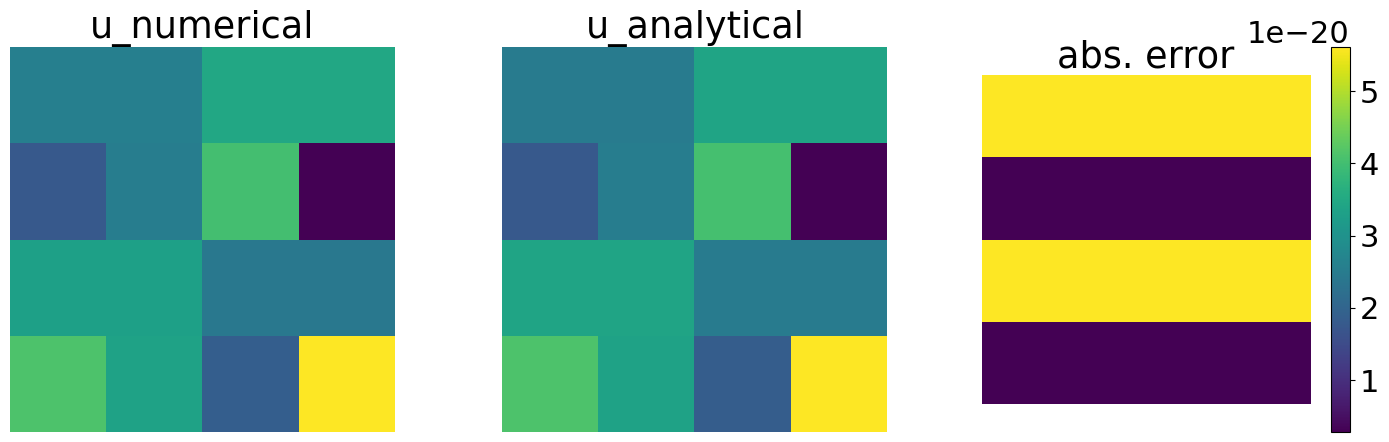

In [94]:
plt.figure(figsize=(18, 5))
plt.rcParams.update({'font.size': 22})
plt.subplot(1, 3, 1)
plt.imshow(u_theo.real, extent=[x_lb, x_rb, y_lb, y_ub], origin='lower')
plt.axis('off')
plt.title("u_numerical")
plt.subplot(1, 3, 2)
plt.imshow(u_spec.real, extent=[x_lb, x_rb, y_lb, y_ub], origin='lower')
plt.axis('off')
plt.title("u_analytical")
plt.subplot(1, 3, 3)
plt.imshow(abs(u_spec-u_theo), extent=[x_lb, x_rb, y_lb, y_ub], origin='lower')
plt.title("abs. error")
plt.colorbar()
plt.axis('off')
#plt.savefig("Poisson2D_num.png", bbox_inches='tight')
#plt.savefig("Elliptic2D_num.png", bbox_inches='tight')



In [95]:
#normalized_u_spec = u_spec / jnp.linalg.norm(u_spec)
#normalized_u_theo = u_theo/ jnp.linalg.norm(u_theo)
error = jnp.linalg.norm(u_spec - u_theo)/jnp.linalg.norm(u_theo)
error

0.051818329330462674

In [96]:
import jax.numpy as jnp
import scipy.linalg

def make_unitary(A):
    N = A.shape[0]
    AhA = A.conj().T @ A                                      # A' * A
    sqrt_term = jnp.array(
        scipy.linalg.sqrtm(jnp.eye(N) - AhA)                 # sqrtm(I - A'A)
    )
    M = jnp.block([
        [A,          sqrt_term],
        [sqrt_term,  -A       ]
    ])
    return M

In [97]:
# Build laplacian in spectral domain
D = jnp.diag( 
    spectral_eigenvalues(N_x)
)


Elliptic_spec = A[0,0]*jnp.kron(D**2, jnp.eye(N_x)) + A[0, 1] * jnp.kron(D, D) + A[1, 0] * jnp.kron(D, D) + A[1, 1]*jnp.kron(jnp.eye(N_x), D**2)


Elliptic_spec = Elliptic_spec.at[0, 0].set(1)
inverse_Elliptic = jnp.linalg.inv(Elliptic_spec)
# Apply MakeUnitary to the inverse elliptic operator
unitary_Elliptic = make_unitary(inverse_Elliptic)

In [104]:
from qiskit.circuit.library import UnitaryGate 
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT

dim = d * n + 1
qc = QuantumCircuit(dim)

# Add d QFT circuits of dimension n, stacked top to bottom
for i in range(d):
    qubits = list(range(i * n, (i + 1) * n))
    qc.append(QFT(n), qubits)

qc.decompose().draw()
# Convert to numpy for Qiskit compatibility
unitary_np = np.array(unitary_Elliptic)

# Create and append the unitary gate to qc
unitary_gate = UnitaryGate(unitary_np)
qc.append(unitary_gate, range(qc.num_qubits))
for i in range(d):
    qubits = list(range(i * n, (i + 1) * n))
    qc.append(QFT(n).inverse(), qubits)

qc.draw()

C:\Users\giaco\AppData\Local\Temp\ipykernel_46520\2830021049.py:12: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n), qubits)
C:\Users\giaco\AppData\Local\Temp\ipykernel_46520\2830021049.py:23: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n).inverse(), qubits)


┌──────┐┌──────────┐┌───────┐
q_0: ┤0     ├┤0         ├┤0      ├
     │  QFT ││          ││  IQFT │
q_1: ┤1     ├┤1         ├┤1      ├
     ├──────┤│          │├───────┤
q_2: ┤0     ├┤2 Unitary ├┤0      ├
     │  QFT ││          ││  IQFT │
q_3: ┤1     ├┤3         ├┤1      ├
     └──────┘│          │└───────┘
q_4: ────────┤4         ├─────────
             └──────────┘

In [110]:
from qiskit.quantum_info import Operator

# Get full unitary from circuit
full_matrix = Operator(qc).data
block_size  = 2**d * N_x

# Extract leading block
leading_block = full_matrix[:block_size, :block_size]

print(f"Full matrix shape:    {full_matrix.shape}")
print(f"Leading block shape:  {leading_block.shape}")

Full matrix shape:    (32, 32)
Leading block shape:  (16, 16)


In [111]:

error1 = jnp.linalg.norm(u_spec - u_theo)/jnp.linalg.norm(u_theo)
error1


Array(0., dtype=float32)

In [112]:
u_quantum= leading_block @ f(xs, ys).flatten()
u_quantum = u_quantum.reshape(N_x, N_x)
error2 = jnp.linalg.norm(u_quantum - u_theo)/jnp.linalg.norm(u_theo)
error2

Array(4.5317546e+08, dtype=float32)

In [113]:
u_quantum

Array([[-2.0324203e-10-1.9845095e-18j, -2.4732588e-10+2.8669274e-18j,
         8.5125668e-10-1.4406712e-18j,  1.3608510e-10+1.4256151e-18j],
       [ 7.6681952e-11-6.9023384e-11j, -2.1089902e-10+6.9023384e-11j,
        -7.6682036e-11-6.9023384e-11j,  2.1089858e-10+6.9023384e-11j],
       [ 2.0324215e-10+1.4406712e-18j,  2.4732466e-10-1.4256151e-18j,
        -8.5125657e-10+1.9845095e-18j, -1.3608586e-10-2.8669274e-18j],
       [-7.6682043e-11+6.9023384e-11j,  2.1089869e-10-6.9023384e-11j,
         7.6681959e-11+6.9023384e-11j, -2.1089823e-10-6.9023384e-11j]],      dtype=complex64)

In [114]:
from qiskit.quantum_info import Operator
import numpy as np

# ── 1. Build the quantum circuit operator ──────────────────────────────────────
full_matrix = Operator(qc).data
block_size  = 2**d * N_x                         # physical subspace size

leading_block = full_matrix[:block_size, :block_size]

# ── 2. Prepare the input vector (same as classical solver) ────────────────────
f_flatten = f(xs, ys).flatten()               # shape: (N_x^2,)

# ── 3. Apply the quantum operator (QFT → U_elliptic → QFT†) ──────────────────
# leading_block already encodes the full pipeline:
#   classical:  GF  @  inverse_Elliptic  @  FG
#   quantum:    QFT† @  U_elliptic        @  QFT
u_flatten_quantum = leading_block @ f_flatten

# ── 4. Reshape and compare ─────────────────────────────────────────────────────
u_quantum = u_flatten_quantum.reshape(N_x, N_x)

error_quantum = jnp.linalg.norm(u_quantum - u_theo) / jnp.linalg.norm(u_theo)
error_spec    = jnp.linalg.norm(u_spec    - u_theo) / jnp.linalg.norm(u_theo)

print(f"Classical spectral error: {error_spec:.6e}")
print(f"Quantum circuit error:    {error_quantum:.6e}")

Classical spectral error: 0.000000e+00
Quantum circuit error:    4.531755e+08
